# Columbia, SC Arrest Data Analysis (2016–2024)  
Portfolio Project – Local Public Safety Insights  

Data Source: City of Columbia Open Data – Arrest (1/1/2016 to 12/31/2024)  
https://coc-colacitygis.opendata.arcgis.com/datasets/ColaCityGIS::arrest-1-1-2016-to-12-31-2024/about  

Note: Coordinates are in SC State Plane feet (likely EPSG:6570). Reproject to WGS84 lat/lon for mapping.

In [ ]:
#!pip install pyproj --quiet

In [ ]:
Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Geospatial & ML
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# For projection fix
from pyproj import Transformer

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [ ]:
#Load Data 
try:
    df = pd.read_csv('arrests_columbia_sc.csv')
    print("Loaded successfully. Shape:", df.shape)
    print("\nColumns:", list(df.columns))
    display(df.head(5))
except FileNotFoundError:
    print("CSV not found. Download from ArcGIS portal and place in this folder.")
    raise

Loaded successfully. Shape: (86471, 14)

Columns: ['X', 'Y', 'OBJECTID', 'Inc_Case', 'Arrest_Date', 'Address', 'City', 'State', 'Zip', 'Race', 'Sex', 'Offense_Description', 'Age', 'Year']


C:\Users\altus\AppData\Local\Temp\ipykernel_13000\498921346.py:3: DtypeWarning: Columns (0: Inc_Case) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('arrests_columbia_sc.csv')


,X,Y,OBJECTID,Inc_Case,Arrest_Date,Address,City,State,Zip,Race,Sex,Offense_Description,Age,Year
0,2.019671e+06,818167.353675,1,120023353,2017/08/06 02:00:00+00,10XX North KINGS STREET,COLUMBIA,SC,29223,NaN,NaN,RESISTING/ASSLT POLICE OFFICER,61,2017
1,2.019671e+06,818167.353675,2,120023353,2017/08/06 02:00:00+00,10XX North KINGS STREET,COLUMBIA,SC,29223,NaN,NaN,POSSESSION/CONSUMPTION OF ALCOHOL IN PUBLIC,61,2017
2,2.019671e+06,818167.353675,3,120023353,2017/08/06 02:00:00+00,10XX North KINGS STREET,COLUMBIA,SC,29223,NaN,NaN,DISORDERLY CONDUCT,61,2017
3,2.019671e+06,818167.353675,4,120023353,2017/08/06 02:00:00+00,10XX North KINGS STREET,COLUMBIA,SC,29223,NaN,NaN,NaN,61,2017
4,2.019671e+06,818167.353675,5,120023353,2017/08/06 02:00:00+00,10XX North KINGS STREET,COLUMBIA,SC,29223,NaN,NaN,SERVICE OF A BENCH WARRANT,61,2017


In [ ]:
# Cleaning & Feature Engineering
# Assume date/time columns exist; adjust names if needed after print above
date_col = 'Arrest_Date'   # from earlier list
if date_col in df.columns:
    df['ARREST_DATETIME'] = pd.to_datetime(df[date_col], errors='coerce')

df['YEAR'] = df['ARREST_DATETIME'].dt.year
df['MONTH'] = df['ARREST_DATETIME'].dt.month
df['DAY_OF_WEEK'] = df['ARREST_DATETIME'].dt.day_name()
df['HOUR'] = df['ARREST_DATETIME'].dt.hour

print("Date parsing done. Missing datetimes:", df['ARREST_DATETIME'].isna().sum())

Date parsing done. Missing datetimes: 0


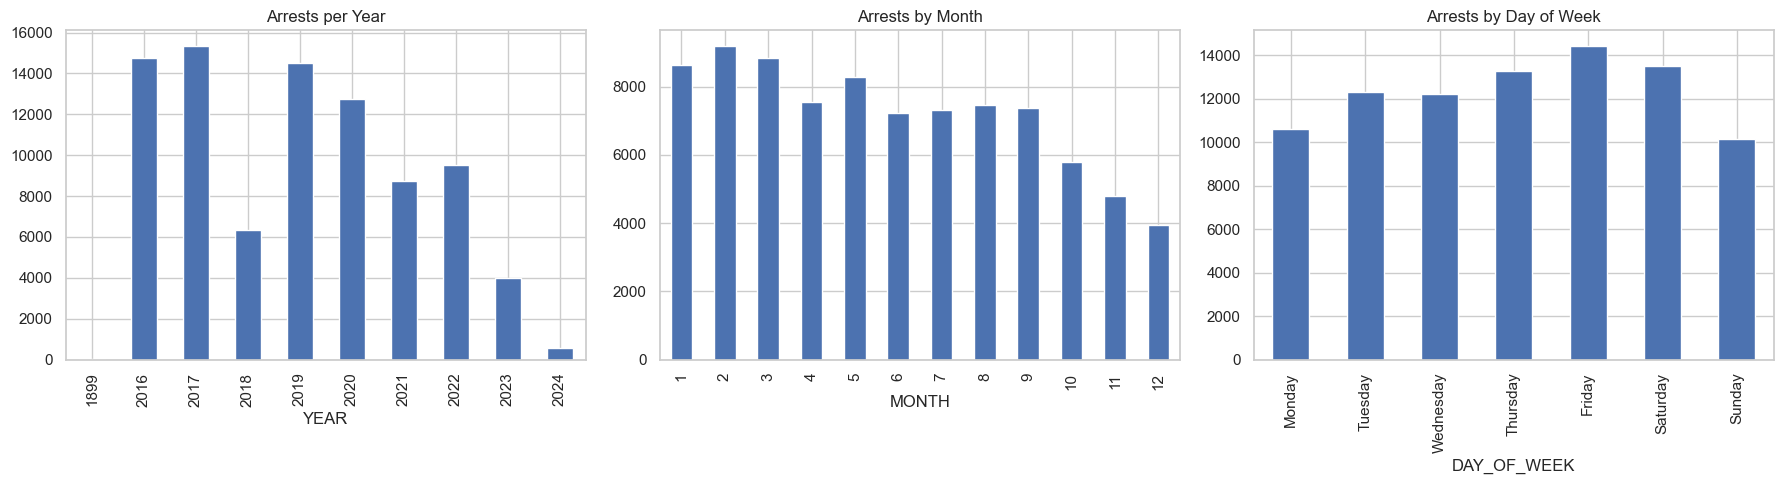

In [ ]:
# Time Series EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By year
df['YEAR'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Arrests per Year')

# By month
df['MONTH'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Arrests by Month')

# By day of week
df['DAY_OF_WEEK'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', ax=axes[2])
axes[2].set_title('Arrests by Day of Week')

plt.tight_layout()
plt.show()

Non-numeric Age values (if any):
<StringArray>
[nan, 'NB', 'BB', 'NN', '29210-']
Length: 5, dtype: str


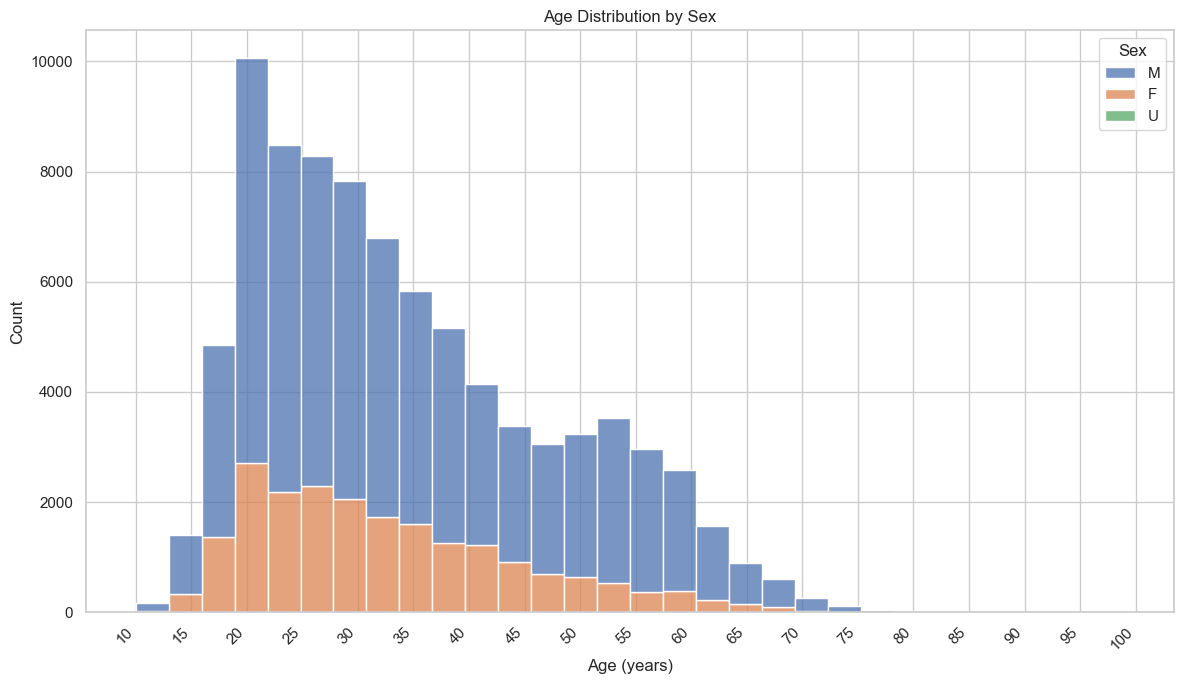


Age Statistics:
count    86196.000000
mean        34.249025
std         13.484766
min         10.000000
25%         23.000000
50%         31.000000
75%         43.000000
max         99.000000
Name: Age_numeric, dtype: float64


In [ ]:
# Age Distribution by Sex – Fixed Version

# Step 1: Convert Age to numeric (coerce errors to NaN)
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Optional: Look at problematic ages (run once to diagnose)
print("Non-numeric Age values (if any):")
print(df[df['Age_numeric'].isna()]['Age'].unique()[:20])  # first 20 bad ones

# Drop rows where Age couldn't be converted (or handle differently)
df_plot = df.dropna(subset=['Age_numeric']).copy()

# Optional: Cap extreme ages if needed (e.g., data entry errors)
df_plot = df_plot[df_plot['Age_numeric'].between(10, 100)]

# Step 2: Plot with numeric Age axis
plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_plot,
    x='Age_numeric',
    hue='Sex',
    multiple='stack',
    bins=30,               
    kde=False,             # optional: add kde=True for smooth curve
    stat='count',
    discrete=False         # important: treat x as continuous numeric
)

plt.title('Age Distribution by Sex')
plt.xlabel('Age (years)')
plt.ylabel('Count')

# Fix x-axis: rotate labels, use reasonable ticks
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))  # limit to ~20 ticks max

# Optional: tighter layout to prevent clipping
plt.tight_layout()

plt.show()

# Bonus: Summary stats for sanity check
print("\nAge Statistics:")
print(df_plot['Age_numeric'].describe())

In [7]:
print("Checking columns in df:")
print(df.columns.tolist())

if 'lon_wgs84' in df.columns and 'lat_wgs84' in df.columns:
    print("\nSample WGS84 coords (should be ~34, -81):")
    display(df[['lat_wgs84', 'lon_wgs84']].head(8))
    print("\nCoordinate ranges:")
    display(df[['lat_wgs84', 'lon_wgs84']].describe())
else:
    print("\nNo 'lat_wgs84' / 'lon_wgs84' columns yet → reprojection didn't succeed.")

Checking columns in df:
['X', 'Y', 'OBJECTID', 'Inc_Case', 'Arrest_Date', 'Address', 'City', 'State', 'Zip', 'Race', 'Sex', 'Offense_Description', 'Age', 'Year', 'ARREST_DATETIME', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'Age_numeric']

No 'lat_wgs84' / 'lon_wgs84' columns yet → reprojection didn't succeed.


In [8]:
# Standalone Reprojection Cell – Run this BEFORE heatmap/clustering
from pyproj import Transformer
import numpy as np
import pandas as pd   # df should already exist from load cell

def try_reproject(epsg):
    try:
        transformer = Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)
        lon, lat = transformer.transform(df['X'].values, df['Y'].values)
        
        df['lon_wgs84'] = lon
        df['lat_wgs84'] = lat
        
        print(f"\nEPSG:{epsg} transformation results:")
        print("Sample transformed (lat, lon):")
        print(df[['lat_wgs84', 'lon_wgs84']].head(10))
        
        print("\nSummary stats (should be lat ~33.9-34.1, lon ~-81.1 to -80.9):")
        print(df[['lat_wgs84', 'lon_wgs84']].describe())
        
        # Simple sanity check
        if (df['lat_wgs84'].between(33.5, 34.5).sum() / len(df) > 0.9) and \
           (df['lon_wgs84'].between(-81.5, -80.5).sum() / len(df) > 0.9):
            print("→ GOOD: Coordinates look correct for Columbia, SC area!")
            return True
        else:
            print("→ Suspicious ranges – this EPSG may be wrong.")
            return False
    except Exception as e:
        print(f"Error with EPSG:{epsg}: {str(e)}")
        return False

# Try modern SC State Plane (International feet) first
success = try_reproject(6570)

if not success:
    print("\nTrying fallback: older NAD83 SC ftUS (EPSG:2273)")
    success = try_reproject(2273)

if success:
    # Clean up any bad values
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['lat_wgs84', 'lon_wgs84'])
    print(f"\nCleaned rows with valid WGS84 coords: {len(df)}")
    print("Reprojection complete – now run the heatmap cell.")
else:
    print("\nBoth EPSG attempts failed. Possible issues:")
    print("- 'X'/'Y' not numeric? Check: df[['X','Y']].dtypes")
    print("- Missing pyproj install? Run !pip install pyproj")
    print("- Data has no valid X/Y? Check: df[['X','Y']].dropna().shape")
    print("Paste the full output here for more help.")


EPSG:6570 transformation results:
Sample transformed (lat, lon):
   lat_wgs84  lon_wgs84
0  34.082059 -80.935027
1  34.082059 -80.935027
2  34.082059 -80.935027
3  34.082059 -80.935027
4  34.082059 -80.935027
5  34.050379 -81.025998
6  34.082276 -81.165620
7  34.082276 -81.165620
8  34.082276 -81.165620
9  34.082276 -81.165620

Summary stats (should be lat ~33.9-34.1, lon ~-81.1 to -80.9):
          lat_wgs84     lon_wgs84
count  86454.000000  86454.000000
mean      34.023955    -81.031889
std        0.030381      0.054524
min       33.871376    -81.726352
25%       34.002942    -81.042316
50%       34.023062    -81.025499
75%       34.040736    -81.011744
max       34.426977    -80.671851
→ GOOD: Coordinates look correct for Columbia, SC area!

Cleaned rows with valid WGS84 coords: 86454
Reprojection complete – now run the heatmap cell.


In [9]:
# Minimal reprojection – creates 'lat' and 'lon' in degrees
from pyproj import Transformer
import numpy as np

# Use EPSG:6570 (most likely correct for recent Columbia SC data in feet)
transformer = Transformer.from_crs("EPSG:6570", "EPSG:4326", always_xy=True)

# Transform X (easting) → lon, Y (northing) → lat
df['lon'], df['lat'] = transformer.transform(df['X'].values, df['Y'].values)

# Quick validation
print("First 8 transformed coordinates (should look like lat ~34, lon ~-81):")
print(df[['lat', 'lon']].head(8))

print("\nLat range (should be ~33.9 to 34.2):", df['lat'].min(), "to", df['lat'].max())
print("Lon range (should be ~-81.1 to -80.9):", df['lon'].min(), "to", df['lon'].max())

# Remove any bad rows
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['lat', 'lon'])
print(f"\nRows ready for mapping: {len(df)}")

First 8 transformed coordinates (should look like lat ~34, lon ~-81):
         lat        lon
0  34.082059 -80.935027
1  34.082059 -80.935027
2  34.082059 -80.935027
3  34.082059 -80.935027
4  34.082059 -80.935027
5  34.050379 -81.025998
6  34.082276 -81.165620
7  34.082276 -81.165620

Lat range (should be ~33.9 to 34.2): 33.871375787820554 to 34.42697656327389
Lon range (should be ~-81.1 to -80.9): -81.72635167537992 to -80.6718514197475

Rows ready for mapping: 86454


In [11]:
# Optional grouping example (customize based on your data)
def simplify_offense(desc):
    desc = str(desc).lower()
    if 'dui' in desc or 'driving under' in desc:
        return 'DUI / Drunk Driving'
    if 'assault' in desc:
        return 'Assault'
    if 'drug' in desc or 'narcotic' in desc:
        return 'Drug Offense'
    if 'theft' in desc or 'larceny' in desc:
        return 'Theft/Larceny'
    # Add more rules as needed
    return desc.title()  # default: capitalize

df['Offense_Group'] = df['Offense_Description'].apply(simplify_offense)

# Then use 'Offense_Group' instead of 'Offense_Description' in the chart code

C:\Users\altus\AppData\Local\Temp\ipykernel_13000\557301472.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


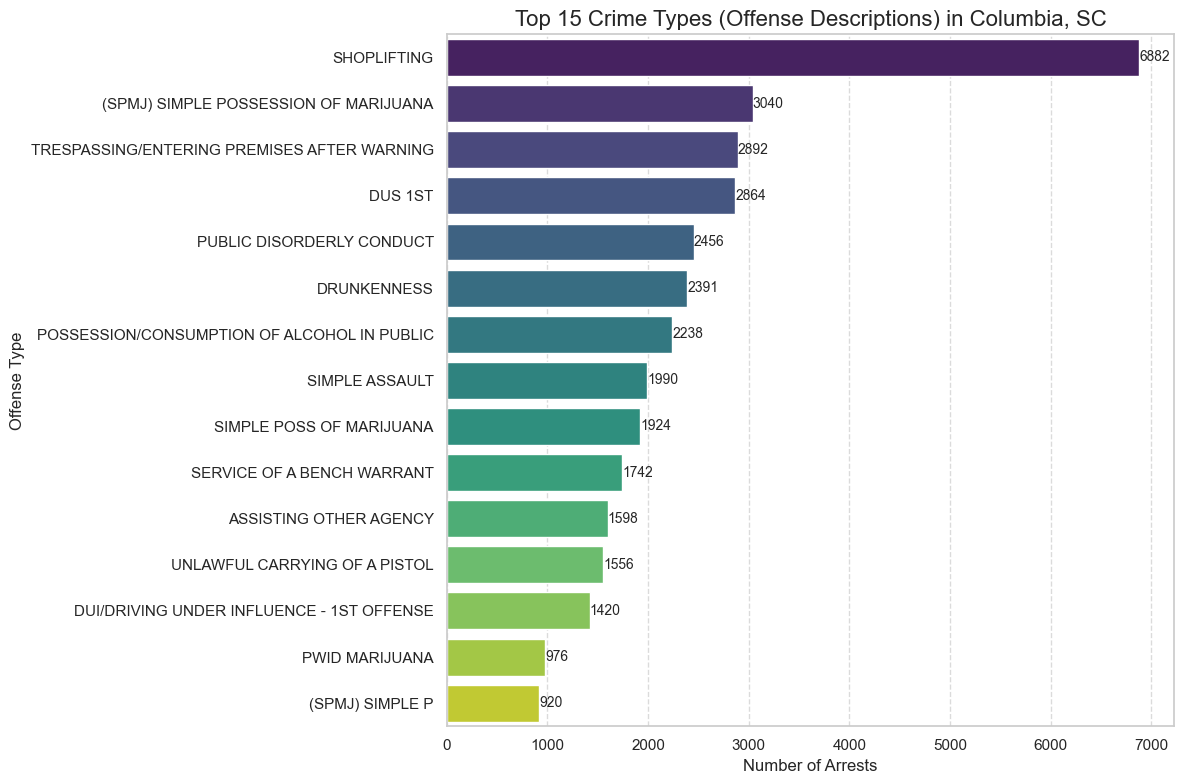


Top 20 Offense Descriptions (full list):
Offense_Description
SHOPLIFTING                                        6882
(SPMJ) SIMPLE POSSESSION OF MARIJUANA              3040
TRESPASSING/ENTERING PREMISES AFTER WARNING        2892
DUS 1ST                                            2864
PUBLIC DISORDERLY CONDUCT                          2456
DRUNKENNESS                                        2391
POSSESSION/CONSUMPTION OF ALCOHOL IN PUBLIC        2238
SIMPLE ASSAULT                                     1990
SIMPLE POSS OF MARIJUANA                           1924
SERVICE OF A BENCH WARRANT                         1742
ASSISTING OTHER AGENCY                             1598
UNLAWFUL CARRYING OF A PISTOL                      1556
DUI/DRIVING UNDER INFLUENCE - 1ST OFFENSE          1420
PWID MARIJUANA                                      976
(SPMJ) SIMPLE P                                     920
DUS 2ND                                             881
MALICIOUS INJURY TO PERSONAL PROPERTY/VAND

In [12]:
# Cell: Distribution of Crime Types (Offense Descriptions)

# Optional: Clean up offense descriptions if needed (e.g., strip extra spaces)
df['Offense_Description'] = df['Offense_Description'].astype(str).str.strip()

# Get top N most common offense types (change 15 to whatever you prefer)
top_n = 15
crime_counts = df['Offense_Description'].value_counts().head(top_n)

# Create the chart
plt.figure(figsize=(12, 8))

# Horizontal bar chart (easier to read long labels)
sns.barplot(
    x=crime_counts.values,
    y=crime_counts.index,
    palette='viridis'
)

plt.title(f'Top {top_n} Crime Types (Offense Descriptions) in Columbia, SC', fontsize=16)
plt.xlabel('Number of Arrests', fontsize=12)
plt.ylabel('Offense Type', fontsize=12)

# Add value labels on bars for clarity
for i, v in enumerate(crime_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10)

# Improve readability
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# Optional: Print full counts for reference
print("\nTop 20 Offense Descriptions (full list):")
print(df['Offense_Description'].value_counts().head(20))

In [ ]:
# Interactive Heatmap (Trust Notebook if blocked!)
valid_df = df.dropna(subset=['lat_wgs84', 'lon_wgs84'])

m = folium.Map(location=[34.0007, -81.0348], zoom_start=12, tiles='CartoDB positron')

heat_data = [[row['lat_wgs84'], row['lon_wgs84']] for _, row in valid_df.iterrows()]
HeatMap(heat_data, radius=12, blur=15).add_to(m)

display(m)